<a href="https://colab.research.google.com/github/CanCengiz1/energy-consumption-ml/blob/main/energy_consumption_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

txt_path = "/content/household_power_consumption.txt"

df = pd.read_csv(
    txt_path, sep=";", low_memory=False,
    na_values=["?", "NA", "nan", ""]
)
df.head(), df.shape


(         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
 0  16/12/2006  17:24:00                4.216                  0.418   234.84   
 1  16/12/2006  17:25:00                5.360                  0.436   233.63   
 2  16/12/2006  17:26:00                5.374                  0.498   233.29   
 3  16/12/2006  17:27:00                5.388                  0.502   233.74   
 4  16/12/2006  17:28:00                3.666                  0.528   235.68   
 
    Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
 0              18.4             0.0             1.0            17.0  
 1              23.0             0.0             1.0            16.0  
 2              23.0             0.0             2.0            17.0  
 3              23.0             0.0             1.0            17.0  
 4              15.8             0.0             1.0            17.0  ,
 (32193, 9))

In [ ]:
df.info()
df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32193 entries, 0 to 32192
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   32193 non-null  object 
 1   Time                   32193 non-null  object 
 2   Global_active_power    32189 non-null  float64
 3   Global_reactive_power  32189 non-null  float64
 4   Voltage                32189 non-null  float64
 5   Global_intensity       32189 non-null  float64
 6   Sub_metering_1         32189 non-null  float64
 7   Sub_metering_2         32188 non-null  float64
 8   Sub_metering_3         32188 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.2+ MB


,0
Sub_metering_2,5
Sub_metering_3,5
Sub_metering_1,4
Global_active_power,4
Global_reactive_power,4
Global_intensity,4
Voltage,4
Date,0
Time,0


In [ ]:
import pandas as pd
import numpy as np

# datetime
df["dt"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce"
)

# index
df = df.dropna(subset=["dt"]).drop(columns=["Date", "Time"])
df = df.sort_values("dt").set_index("dt")

df.head(), df.index.min(), df.index.max()


(                     Global_active_power  Global_reactive_power  Voltage  \
 dt                                                                         
 2006-12-16 17:24:00                4.216                  0.418   234.84   
 2006-12-16 17:25:00                5.360                  0.436   233.63   
 2006-12-16 17:26:00                5.374                  0.498   233.29   
 2006-12-16 17:27:00                5.388                  0.502   233.74   
 2006-12-16 17:28:00                3.666                  0.528   235.68   
 
                      Global_intensity  Sub_metering_1  Sub_metering_2  \
 dt                                                                      
 2006-12-16 17:24:00              18.4             0.0             1.0   
 2006-12-16 17:25:00              23.0             0.0             1.0   
 2006-12-16 17:26:00              23.0             0.0             2.0   
 2006-12-16 17:27:00              23.0             0.0             1.0   
 2006-12-16 17:

In [ ]:
# Interpolate short gaps (ex:up to 60 mins)
df = df.interpolate(method="time", limit=60)

# Fill in the blanks
df = df.ffill().bfill()

# control
df.isna().sum().sum()


np.int64(0)

In [ ]:
df_h = df.resample("h").mean()
df_h.shape



(537, 7)

In [ ]:
target = "Global_active_power"

df_h.columns, df_h[target].describe()


(Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
        'Sub_metering_3'],
       dtype='object'),
 count    537.000000
 mean       1.770699
 std        1.184570
 min        0.246733
 25%        0.573500
 50%        1.688233
 75%        2.541667
 max        5.562467
 Name: Global_active_power, dtype: float64)

In [ ]:
# Time features
df_h["hour"] = df_h.index.hour
df_h["dayofweek"] = df_h.index.dayofweek
df_h["month"] = df_h.index.month
df_h["is_weekend"] = (df_h["dayofweek"] >= 5).astype(int)

# Lag features
for lag in [1, 2, 24, 48, 168]:
    df_h[f"{target}_lag_{lag}"] = df_h[target].shift(lag)

# Rolling features
df_h[f"{target}_roll_24_mean"] = df_h[target].rolling(24).mean()
df_h[f"{target}_roll_168_mean"] = df_h[target].rolling(168).mean()

# Drop NaNs introduced by lag/rolling
df_h = df_h.dropna()

df_h.shape, df_h.head()


((369, 18),
                      Global_active_power  Global_reactive_power     Voltage  \
 dt                                                                            
 2006-12-23 17:00:00             5.452533               0.215967  233.644167   
 2006-12-23 18:00:00             3.879400               0.099767  238.000500   
 2006-12-23 19:00:00             4.117833               0.205333  238.729333   
 2006-12-23 20:00:00             4.181400               0.124767  238.518833   
 2006-12-23 21:00:00             3.288433               0.235767  238.594667   
 
                      Global_intensity  Sub_metering_1  Sub_metering_2  \
 dt                                                                      
 2006-12-23 17:00:00         23.360000       16.183333        0.666667   
 2006-12-23 18:00:00         16.363333        0.000000        0.016667   
 2006-12-23 19:00:00         17.300000        0.000000        0.600000   
 2006-12-23 20:00:00         17.596667        0.000000  

**EDA**

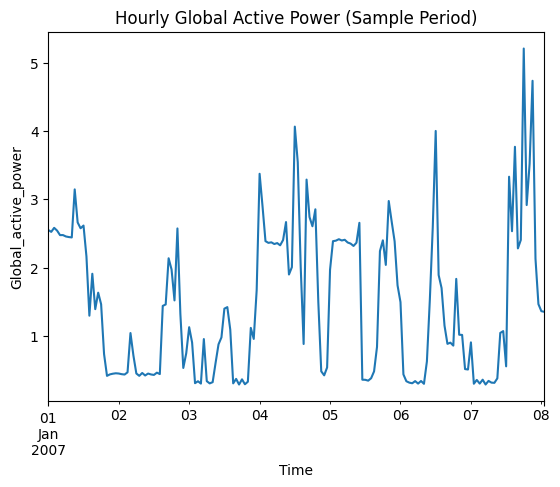

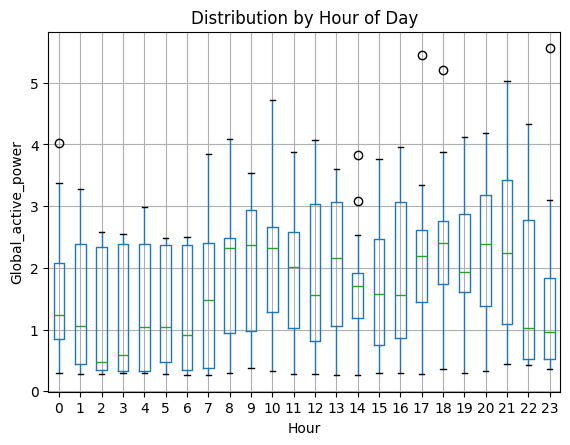

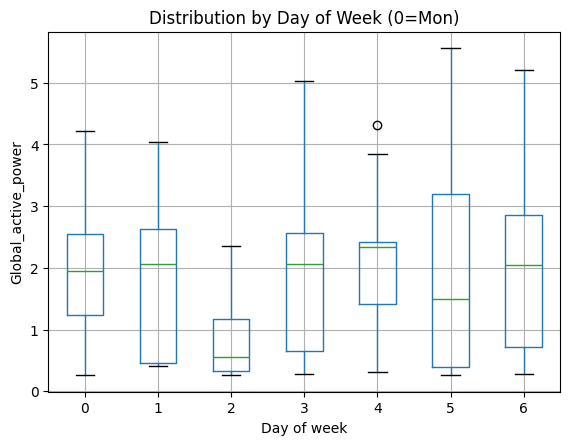

In [ ]:
import matplotlib.pyplot as plt

target = "Global_active_power"

# 1) Sample period trend (First 3 months)
df_h[target].loc["2007-01-01":"2007-03-31"].plot()
plt.title("Hourly Global Active Power (Sample Period)")
plt.xlabel("Time"); plt.ylabel(target)
plt.show()

# 2) Hour-of-day effect
df_h.boxplot(column=target, by="hour", rot=0)
plt.title("Distribution by Hour of Day")
plt.suptitle("")
plt.xlabel("Hour"); plt.ylabel(target)
plt.show()

# 3) Day-of-week effect
df_h.boxplot(column=target, by="dayofweek", rot=0)
plt.title("Distribution by Day of Week (0=Mon)")
plt.suptitle("")
plt.xlabel("Day of week"); plt.ylabel(target)
plt.show()


**regression_metrics**

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


**Chronological Train/Test Split (No Shuffle)**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = [c for c in df_h.columns if c != target]
X = df_h[features]
y = df_h[target]

split_idx = int(len(df_h) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train range:", X_train.index.min(), "->", X_train.index.max())
print("Test range:", X_test.index.min(), "->", X_test.index.max())


Train: (295, 17) Test: (74, 17)
Train range: 2006-12-23 17:00:00 -> 2007-01-04 23:00:00
Test range: 2007-01-05 00:00:00 -> 2007-01-08 01:00:00


**Model 1 - Naive (Baseline)**

In [ ]:
y_pred_naive = y_test.shift(1).bfill()

mae_naive, rmse_naive, r2_naive = regression_metrics(y_test, y_pred_naive)

print("Naive  MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)
print("Naive   R2:", r2_naive)


Naive  MAE: 0.5126188952110005
Naive RMSE: 0.8772410696172473
Naive   R2: 0.4318519460654332


**Model 2 - Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf, rmse_rf, r2_rf = regression_metrics(y_test, y_pred_rf)

print("RF  MAE:", mae_rf)
print("RF RMSE:", rmse_rf)
print("RF   R2:", r2_rf)


RF  MAE: 0.029443896080290907
RF RMSE: 0.04695597820014761
RF   R2: 0.9983721836864055


**Model 3 - XGBoost**

In [ ]:
!pip -q install xgboost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb, rmse_xgb, r2_xgb = regression_metrics(y_test, y_pred_xgb)

print("XGB  MAE:", mae_xgb)
print("XGB RMSE:", rmse_xgb)
print("XGB   R2:", r2_xgb)


XGB  MAE: 0.08906188498200143
XGB RMSE: 0.12585572315869897
XGB   R2: 0.9883058260197738


**Result Table**

In [ ]:
import pandas as pd
results = pd.DataFrame({
    "Model": ["Naive", "RandomForest", "XGBoost"],
    "MAE": [mae_naive, mae_rf, mae_xgb],
    "RMSE": [rmse_naive, rmse_rf, rmse_xgb],
    "R2": [r2_naive, r2_rf, r2_xgb]
}).sort_values("RMSE")

results




,Model,MAE,RMSE,R2
1,RandomForest,0.029444,0.046956,0.998372
2,XGBoost,0.089062,0.125856,0.988306
0,Naive,0.512619,0.877241,0.431852


**Actual vs Predicted Graphs**

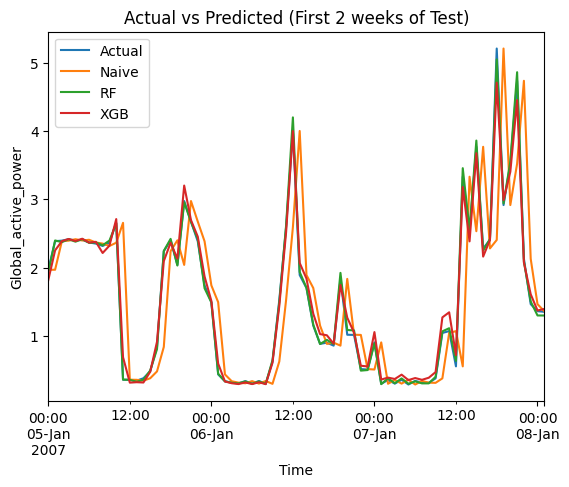

In [ ]:
import matplotlib.pyplot as plt
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Naive": y_pred_naive.values,
    "RF": y_pred_rf,
    "XGB": y_pred_xgb
}, index=y_test.index)

pred_df.iloc[:24*14].plot()  # 2 weeks of test
plt.title("Actual vs Predicted (First 2 weeks of Test)")
plt.xlabel("Time")
plt.ylabel(target)
plt.show()

**Feature Importance (RandomForest)**

In [ ]:
import pandas as pd

fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
fi.head(15)


,0
Global_intensity,0.997255
hour,0.000385
Global_active_power_lag_1,0.000338
Sub_metering_1,0.000338
Global_active_power_roll_24_mean,0.000267
Global_active_power_roll_168_mean,0.000179
Voltage,0.000175
Global_active_power_lag_24,0.000158
Sub_metering_2,0.000154
Global_active_power_lag_48,0.000151
